<a href="https://colab.research.google.com/github/jeosol/llm-post-training/blob/main/rlhf_from_scratch/1_SFT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Supervised Fine-Tuning (SFT)

Supervised Fine-Tuning (SFT) is the first step in the entire RLHF fine-tuning pipeline (see Figure 2 in RLHF paper). This notebook would use gpt2 and the corresponding tokenizer model from Hugging Face transformers library to perform SFT on stanfordnlp/sst2 dataset.

## Initialise gpt2 tokenizer and model

In [42]:
from transformers import AutoModelForCausalLM, AutoTokenizer
model_name = 'gpt2'
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForCausalLM.from_pretrained(model_name)

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


## Testing the Tokenizer



### Encoding

In [43]:
text = "Hello, this is the first step of RLHF training."
tokens = tokenizer(text)
print(tokens)

{'input_ids': [15496, 11, 428, 318, 262, 717, 2239, 286, 45715, 29567, 3047, 13], 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]}


### Decoding

In [44]:
print(tokenizer.decode(tokens['input_ids']))

Hello, this is the first step of RLHF training.


### Tokenize a batch

In [45]:
texts = ['Hello, this is the first step of RLHF training.', 'I have a dog', 'I also have a cat']
tokens_obj = tokenizer(texts)

In [46]:
for tokens in tokens_obj['input_ids']:
    print(tokenizer.decode(tokens))

Hello, this is the first step of RLHF training.
I have a dog
I also have a cat


## Working with a dataset


In [47]:
%pip install datasets==3.5.0

### Loading a dataset

In [48]:
from datasets import load_dataset
dataset_name = 'sst2'
ds = load_dataset(dataset_name)

In [49]:
ds

DatasetDict({
    train: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 67349
    })
    validation: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 872
    })
    test: Dataset({
        features: ['idx', 'sentence', 'label'],
        num_rows: 1821
    })
})

In [50]:
ds_train, ds_val = ds['train'], ds['validation']
ds_train

Dataset({
    features: ['idx', 'sentence', 'label'],
    num_rows: 67349
})

In [51]:
ds_train[6]

{'idx': 6,
 'sentence': 'demonstrates that the director of such hollywood blockbusters as patriot games can still turn out a small , personal film with an emotional wallop . ',
 'label': 1}

In [52]:
# A batch of rows
ds_train[:10] # collation

{'idx': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9],
 'sentence': ['hide new secretions from the parental units ',
  'contains no wit , only labored gags ',
  'that loves its characters and communicates something rather beautiful about human nature ',
  'remains utterly satisfied to remain the same throughout ',
  'on the worst revenge-of-the-nerds clichés the filmmakers could dredge up ',
  "that 's far too tragic to merit such superficial treatment ",
  'demonstrates that the director of such hollywood blockbusters as patriot games can still turn out a small , personal film with an emotional wallop . ',
  'of saucy ',
  "a depressed fifteen-year-old 's suicidal poetry ",
  "are more deeply thought through than in most ` right-thinking ' films "],
 'label': [0, 0, 1, 0, 0, 0, 1, 1, 0, 1]}

## Tokenizing a Dataset

In [53]:
def tokenize(batch):
    return tokenizer(batch['sentence'])

map_kwargs = {
    'batched': True,
    'batch_size': 512,
    'remove_columns': ['idx', 'sentence', 'label']
}

tokenized_dataset_train = ds_train.map(tokenize, **map_kwargs)
tokenized_dataset_val = ds_val.map(tokenize, **map_kwargs)

In [54]:
tokenized_dataset_train[0]

{'input_ids': [24717, 649, 3200, 507, 422, 262, 21694, 4991, 220],
 'attention_mask': [1, 1, 1, 1, 1, 1, 1, 1, 1]}

In [55]:
tokenized_dataset_train[5:10]

{'input_ids': [[5562,
   705,
   82,
   1290,
   1165,
   15444,
   284,
   17004,
   884,
   31194,
   3513,
   220],
  [26567,
   2536,
   689,
   326,
   262,
   3437,
   286,
   884,
   289,
   31777,
   2512,
   30181,
   355,
   29408,
   1830,
   460,
   991,
   1210,
   503,
   257,
   1402,
   837,
   2614,
   2646,
   351,
   281,
   7016,
   3355,
   404,
   764,
   220],
  [1659, 473, 84, 948, 220],
  [64, 19095, 17280, 12, 1941, 12, 727, 705, 82, 26781, 19518, 220],
  [533,
   517,
   7744,
   1807,
   832,
   621,
   287,
   749,
   4600,
   826,
   12,
   28973,
   705,
   7328,
   220]],
 'attention_mask': [[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1,
   1],
  [1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1],
  [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]]}

### Decoding from the dataset


In [56]:
for i, seq in enumerate(tokenized_dataset_train[5:10]['input_ids']):
    print(f'{i+1}: {tokenizer.decode(seq)}')

1: that 's far too tragic to merit such superficial treatment 
2: demonstrates that the director of such hollywood blockbusters as patriot games can still turn out a small , personal film with an emotional wallop . 
3: of saucy 
4: a depressed fifteen-year-old 's suicidal poetry 
5: are more deeply thought through than in most ` right-thinking ' films 


### Filter out tweets shorter than 5 tokens

In [57]:
# Print the length of the unfiltered train and validation datasets
print(len(tokenized_dataset_train), len(tokenized_dataset_val))

67349 872


In [58]:
tokenized_dataset_train = tokenized_dataset_train.filter(lambda x: len(x['input_ids']) > 5)
tokenized_dataset_val = tokenized_dataset_val.filter(lambda x: len(x['input_ids']) > 5)

In [59]:
# print the length of the filtered train and validation datasets
print(len(tokenized_dataset_train), len(tokenized_dataset_val))

49401 867


## Preparing a dataloader

### Set PyTorch format

In [60]:
# Converts the dataset to tensor format
tokenized_dataset_train.set_format(type='torch')
tokenized_dataset_val.set_format(type='torch')

In [61]:
tokenized_dataset_train[0]

{'input_ids': tensor([24717,   649,  3200,   507,   422,   262, 21694,  4991,   220]),
 'attention_mask': tensor([1, 1, 1, 1, 1, 1, 1, 1, 1])}

In [62]:
tokenized_dataset_train[:5]

{'input_ids': [tensor([24717,   649,  3200,   507,   422,   262, 21694,  4991,   220]),
  tensor([ 3642,  1299,   645, 20868,   837,   691,  2248,  1850,   308,  3775,
            220]),
  tensor([ 5562, 10408,   663,  3435,   290, 48556,  1223,  2138,  4950,   546,
           1692,  3450,   220]),
  tensor([ 2787,  1299, 15950, 11378,   284,  3520,   262,   976,  3690,   220]),
  tensor([  261,   262,  5290, 15827,    12,  1659,    12,  1169,    12,  1008,
           9310, 35478, 20954,   262, 28303,   714, 47478,   469,   510,   220])],
 'attention_mask': [tensor([1, 1, 1, 1, 1, 1, 1, 1, 1]),
  tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
  tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
  tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1]),
  tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])]}

### Padding

In [63]:
# check what the pad token is set to (should be empty)
print(tokenizer.pad_token)

None


In [64]:
# check what the eos token is set to
print(tokenizer.eos_token)

<|endoftext|>


In [65]:
# N+ Implementation paper (page 5) says otherwise
# but we would use attention_mask to remove extra eos_token used for padding
tokenizer.pad_token = tokenizer.eos_token

### Collation with Padding

In [66]:
from torch.utils.data import DataLoader
from transformers import DataCollatorForLanguageModeling
data_collator = DataCollatorForLanguageModeling(tokenizer, mlm=False) # labels

dataloader_params = {
    'batch_size': 32,
    'collate_fn': data_collator
}

train_dataloader = DataLoader(tokenized_dataset_train, **dataloader_params)
val_dataloader = DataLoader(tokenized_dataset_val, **dataloader_params)

In [67]:
len(train_dataloader)

1544

In [68]:
1544*32

49408

In [69]:
batch = next(iter(train_dataloader))
print(batch.keys())

KeysView({'input_ids': tensor([[24717,   649,  3200,  ..., 50256, 50256, 50256],
        [ 3642,  1299,   645,  ..., 50256, 50256, 50256],
        [ 5562, 10408,   663,  ..., 50256, 50256, 50256],
        ...,
        [  672, 35260,   284,  ..., 50256, 50256, 50256],
        [ 1169,  2104,   966,  ..., 50256, 50256, 50256],
        [  292,   484,  1282,  ..., 50256, 50256, 50256]]), 'attention_mask': tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]]), 'labels': tensor([[24717,   649,  3200,  ...,  -100,  -100,  -100],
        [ 3642,  1299,   645,  ...,  -100,  -100,  -100],
        [ 5562, 10408,   663,  ...,  -100,  -100,  -100],
        ...,
        [  672, 35260,   284,  ...,  -100,  -100,  -100],
        [ 1169,  2104,   966,  ...,  -100,  -100,  -100],
        [  292,   484,  1282,  ...,  -100,  -100,  -100]])})


In [70]:
batch['input_ids'].shape

torch.Size([32, 35])

In [71]:
batch['input_ids'][0]

tensor([24717,   649,  3200,   507,   422,   262, 21694,  4991,   220, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256, 50256,
        50256, 50256, 50256, 50256, 50256])

In [72]:
batch['labels'][0]

tensor([24717,   649,  3200,   507,   422,   262, 21694,  4991,   220,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,  -100,
         -100,  -100,  -100,  -100,  -100])

In [73]:
batch['attention_mask'][0]

tensor([1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

## Supervised Fine-tuning (SFT)

In [74]:
import torch
import matplotlib.pyplot as plt

optimizer = torch.optim.AdamW(model.parameters(), lr=5e-5)
# train for one complete pass of the entire training dataset through the neural network including the both forward and bcakward passes to update model parameters.
num_epochs = 10

# Initialize the storage
batch_losses = []
val_losses = []

### Training loop

In [75]:
# Validation Loss:
# While the training loss is often plotted per batch,
# validation loss is typically calculated once per epoch because running a full
# validation pass after every single training batch is computationally expensive
def validate(epoch):
    model.eval()
    total_loss = 0.0
    for i, batch in enumerate(val_dataloader):
        # iteration = epoch * len(val_dataloader) + i
        batch = batch.to(device)
        with torch.no_grad():
            outputs = model(**batch)
            loss = outputs.loss # Uses transformers.loss.loss_utils.ForCausalLMLoss for loss calculation
            total_loss += loss.item()
    mean_val_loss = total_loss / len(val_dataloader)
    print(f'val_loss at {epoch} epoch:', mean_val_loss)
    return mean_val_loss

Code for loss calculation: transformers.loss.loss_utils.ForCausalLMLoss https://github.com/huggingface/transformers/blob/main/src/transformers/loss/loss_utils.py

In [76]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

Streaming output truncated to the last 5000 lines.
Batch: 1181, Loss: 1.211490273475647
Batch: 1182, Loss: 1.0980571508407593
Batch: 1183, Loss: 1.1142609119415283
Batch: 1184, Loss: 0.9800812602043152
Batch: 1185, Loss: 0.9523282647132874
Batch: 1186, Loss: 1.0766199827194214
Batch: 1187, Loss: 0.9925134181976318
Batch: 1188, Loss: 0.9584056735038757
Batch: 1189, Loss: 0.9310157299041748
Batch: 1190, Loss: 1.1274946928024292
Batch: 1191, Loss: 1.0918710231781006
Batch: 1192, Loss: 1.2760090827941895
Batch: 1193, Loss: 1.1610751152038574
Batch: 1194, Loss: 1.2199443578720093
Batch: 1195, Loss: 1.042373538017273
Batch: 1196, Loss: 1.2605781555175781
Batch: 1197, Loss: 1.2146052122116089
Batch: 1198, Loss: 1.2691988945007324
Batch: 1199, Loss: 1.0517452955245972
Batch: 1200, Loss: 0.8492854833602905
Batch: 1201, Loss: 1.157553791999817
Batch: 1202, Loss: 1.2060296535491943
Batch: 1203, Loss: 0.9275699257850647
Batch: 1204, Loss: 1.1689295768737793
Batch: 1205, Loss: 0.9229432940483093
Ba

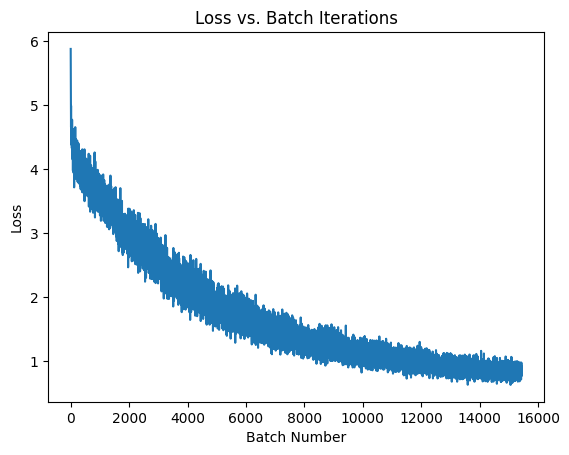

Text(0.5, 1.0, 'Validation Loss vs. Epochs')

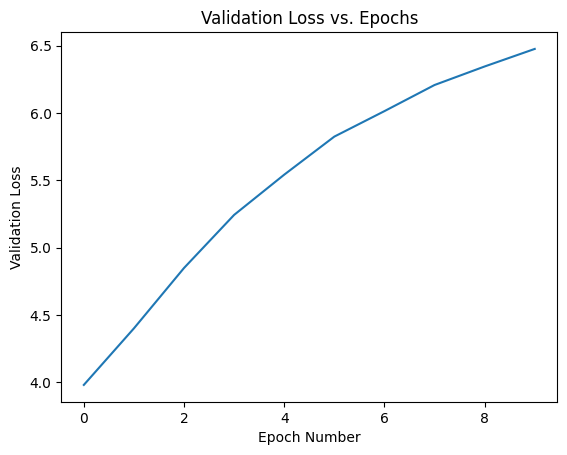

In [77]:
# For GPU (torch.cuda)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model.to(device)
validate(0)
for epoch in range(num_epochs):
    model.train()
    for i, batch in enumerate(train_dataloader):
        batch = batch.to(device)
        outputs = model(**batch)
        loss = outputs.loss
        print(f'Batch: {i+1}, Loss: {loss.item()}')
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        # Record the loss for this batch
        batch_losses.append(loss.item())
    mean_val_loss = validate(epoch+1)
    val_losses.append(mean_val_loss)

# Smoothing: Plotting every single batch can result in noisy graph. For a clearer
# trend, you can plot the moving average or record the average loss every N batches

# Plot the Training Loss vs. Batch
plt.plot(batch_losses)
plt.xlabel('Batch Number')
plt.ylabel('Loss')
plt.title('Loss vs. Batch Iterations')
plt.show()

# Add a plot of the validation loss
plt.figure()
plt.plot(val_losses)
plt.xlabel('Epoch Number')
plt.ylabel('Validation Loss')
plt.title('Validation Loss vs. Epochs')


### Save the model

In [78]:
model.save_pretrained('./sft_model_epoch_10')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

In [79]:
model.from_pretrained('./sft_model_epoch_10')

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel(
  (transformer): GPT2Model(
    (wte): Embedding(50257, 768)
    (wpe): Embedding(1024, 768)
    (drop): Dropout(p=0.1, inplace=False)
    (h): ModuleList(
      (0-11): 12 x GPT2Block(
        (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (attn): GPT2Attention(
          (c_attn): Conv1D(nf=2304, nx=768)
          (c_proj): Conv1D(nf=768, nx=768)
          (attn_dropout): Dropout(p=0.1, inplace=False)
          (resid_dropout): Dropout(p=0.1, inplace=False)
        )
        (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        (mlp): GPT2MLP(
          (c_fc): Conv1D(nf=3072, nx=768)
          (c_proj): Conv1D(nf=768, nx=3072)
          (act): NewGELUActivation()
          (dropout): Dropout(p=0.1, inplace=False)
        )
      )
    )
    (ln_f): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
  )
  (lm_head): Linear(in_features=768, out_features=50257, bias=False)
)

### Zip the saved model (Optional)

In [80]:
!zip -r sft_model_epoch_10.zip sft_model_epoch_10/

  adding: sft_model_epoch_10/ (stored 0%)
  adding: sft_model_epoch_10/config.json (deflated 52%)
  adding: sft_model_epoch_10/model.safetensors (deflated 7%)
  adding: sft_model_epoch_10/generation_config.json (deflated 25%)
